In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv("../data/processed/master_dataset.csv")

print(df.shape)

df.head()

(2693087, 12)


,session_id,timestamp,coolant_temp,map,rpm,speed,iat,maf,throttle_pos,ambient_temp,pedal_d,pedal_e
0,2017-07-05_Seat_Leon_RT_S_Stau,0.813,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
1,2017-07-05_Seat_Leon_RT_S_Stau,0.901,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
2,2017-07-05_Seat_Leon_RT_S_Stau,0.991,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
3,2017-07-05_Seat_Leon_RT_S_Stau,1.081,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
4,2017-07-05_Seat_Leon_RT_S_Stau,1.171,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5


In [3]:
df["speed_delta"] = (
    df.groupby("session_id")["speed"]
      .diff()
)

df["rpm_delta"] = (
    df.groupby("session_id")["rpm"]
      .diff()
)

df["maf_delta"] = (
    df.groupby("session_id")["maf"]
      .diff()
)

df["map_delta"] = (
    df.groupby("session_id")["map"]
      .diff()
)

df["throttle_delta"] = (
    df.groupby("session_id")["throttle_pos"]
      .diff()
)

In [4]:
FEATURES = [
    "rpm",
    "speed",
    "maf",
    "map",
    "throttle_pos",
    "rpm_delta",
    "speed_delta",
    "maf_delta",
    "map_delta",
    "throttle_delta"
]

X = df[FEATURES].fillna(0)

print(X.shape)

(2693087, 10)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2693087, 10)


In [6]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

print("Training Complete")

Training Complete


In [7]:
predictions = iso_forest.predict(X_scaled)

df["anomaly"] = predictions

df["anomaly"].value_counts()

anomaly
 1    2666156
-1      26931
Name: count, dtype: int64

In [8]:
df["anomaly_flag"] = (
    df["anomaly"] == -1
).astype(int)

df["anomaly_flag"].value_counts()

anomaly_flag
0    2666156
1      26931
Name: count, dtype: int64

In [9]:
df["anomaly_flag"].mean() * 100

np.float64(1.0000048271741686)

In [10]:
df["anomaly_score"] = (
    iso_forest.decision_function(X_scaled)
)

df["anomaly_score"].describe()

count    2.693087e+06
mean     1.869103e-01
std      5.237578e-02
min     -1.360834e-01
25%      1.765999e-01
50%      2.089044e-01
75%      2.197802e-01
max      2.345332e-01
Name: anomaly_score, dtype: float64

In [11]:
df.nsmallest(
    20,
    "anomaly_score"
)[
    [
        "session_id",
        "rpm",
        "speed",
        "maf",
        "map",
        "throttle_pos",
        "anomaly_score"
    ]
]

,session_id,rpm,speed,maf,map,throttle_pos,anomaly_score
2639436,2018-04-23_Seat_Leon_RT_KA_Normal,172.0,0.0,1.19,36.0,13.7,-0.136083
3313,2017-07-05_Seat_Leon_RT_S_Stau,175.0,0.0,1.13,36.0,13.7,-0.135139
192114,2017-07-07_Seat_Leon_S_RT_Normal,189.0,0.0,1.52,36.0,13.7,-0.135139
389436,2017-07-12_Seat_Leon_S_RT_Normal,191.0,0.0,1.22,36.0,13.7,-0.135139
391056,2017-07-12_Seat_Leon_S_RT_Normal,180.0,0.0,1.22,36.0,13.7,-0.135139
457530,2017-07-13_Seat_Leon_RT_KA_Stau_Messfehler,201.0,0.0,1.19,36.0,13.7,-0.135139
524620,2017-07-14_Seat_Leon_KA_RT_Normal,201.0,0.0,1.33,36.0,13.7,-0.135139
584457,2017-07-26_Seat_Leon_RT_S_Stau,194.0,0.0,1.36,36.0,13.7,-0.135139
654687,2017-07-27_Seat_Leon_KA_KA_2_Normal,201.0,0.0,1.66,36.0,13.7,-0.135139
807020,2017-07-31_Seat_Leon_RT_KA_Normal,194.0,0.0,1.27,36.0,13.7,-0.135139


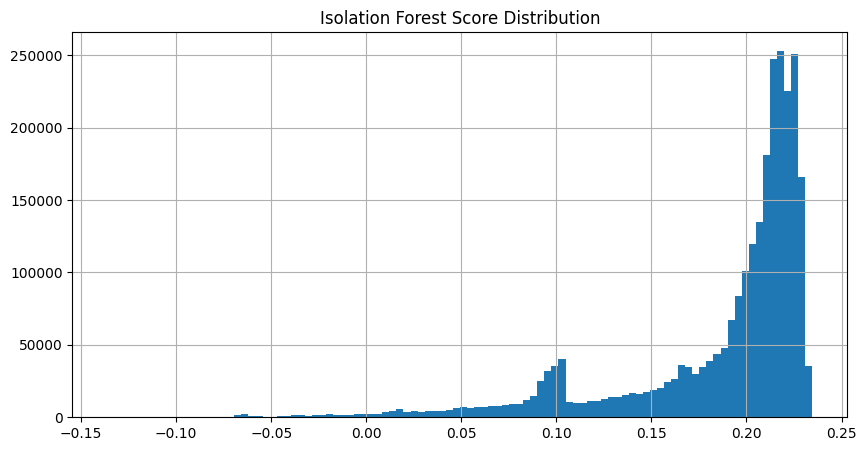

In [12]:
plt.figure(figsize=(10,5))

df["anomaly_score"].hist(
    bins=100
)

plt.title(
    "Isolation Forest Score Distribution"
)

plt.show()

In [13]:
session_anomalies = (
    df.groupby("session_id")
      ["anomaly_flag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

session_anomalies.head(20)

session_id
2017-07-13_Seat_Leon_RT_KA_Stau_Messfehler      3.959748
2017-08-07_Seat_Leon_KA_RT_Frei                 3.749726
2017-07-05_Seat_Leon_S_KA_Normal                3.395222
2017-08-07_Seat_Leon_RT_KA_Frei_Vollbremsung    2.411703
2018-02-18_Seat_Leon_RT_KA_Stau                 2.284801
2017-08-01_Seat_Leon_KA_RT_Normal               2.243241
2017-07-11_Seat_Leon_KA_S_Normal                2.188056
2017-07-31_Seat_Leon_RT_KA_Normal               2.004466
2017-07-10_Seat_Leon_KA_KA_Stau                 1.971018
2018-02-26_Seat_Leon_RT_KA_Normal               1.879401
2017-07-06_Seat_Leon_KA_KA_Normal               1.872721
2017-07-27_Seat_Leon_KA_KA_Normal               1.664948
2018-03-19_Seat_Leon_RT_KA_Normal               1.656432
2017-07-11_Seat_Leon_KA_KA_Stau                 1.645746
2018-03-29_Seat_Leon_KA_RT_Stau                 1.628484
2017-07-28_Seat_Leon_KA_KA_Normal               1.603394
2018-02-27_Seat_Leon_KA_RT_Normal               1.578080
2017-07-27_Seat_Leon

In [14]:
df.nsmallest(
    20,
    "anomaly_score"
)[
    [
        "rpm",
        "speed",
        "maf",
        "map",
        "throttle_pos",
        "rpm_delta",
        "speed_delta",
        "maf_delta",
        "map_delta",
        "throttle_delta"
    ]
]

,rpm,speed,maf,map,throttle_pos,rpm_delta,speed_delta,maf_delta,map_delta,throttle_delta
2639436,172.0,0.0,1.19,36.0,13.7,-621.0,0.0,0.0,0.0,0.0
3313,175.0,0.0,1.13,36.0,13.7,-578.0,0.0,0.0,0.0,0.0
192114,189.0,0.0,1.52,36.0,13.7,-599.0,0.0,0.0,0.0,0.0
389436,191.0,0.0,1.22,36.0,13.7,-588.0,0.0,0.0,0.0,0.0
391056,180.0,0.0,1.22,36.0,13.7,-618.0,0.0,0.0,0.0,0.0
457530,201.0,0.0,1.19,36.0,13.7,-628.0,0.0,0.0,0.0,0.0
524620,201.0,0.0,1.33,36.0,13.7,-600.0,0.0,0.0,0.0,0.0
584457,194.0,0.0,1.36,36.0,13.7,-576.0,0.0,0.0,0.0,0.0
654687,201.0,0.0,1.66,36.0,13.7,-549.0,0.0,0.0,0.0,0.0
807020,194.0,0.0,1.27,36.0,13.7,-587.0,0.0,0.0,0.0,0.0


In [15]:
df.groupby("state")["anomaly_flag"].mean() * 100

KeyError: 'state'

In [18]:
from server.analytics.state_classifier import classify_states

ModuleNotFoundError: No module named 'server'

In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [20]:
from server.analytics.state_classifier import classify_states

print("Import successful")

Import successful


In [21]:
classified_df, report = classify_states(df)

print(classified_df.shape)


(2693087, 21)


In [22]:
classified_df.columns

Index(['session_id', 'timestamp', 'coolant_temp', 'map', 'rpm', 'speed', 'iat',
       'maf', 'throttle_pos', 'ambient_temp', 'pedal_d', 'pedal_e',
       'speed_delta', 'rpm_delta', 'maf_delta', 'map_delta', 'throttle_delta',
       'anomaly', 'anomaly_flag', 'anomaly_score', 'state'],
      dtype='str')

In [23]:
classified_df, report = classify_states(df)

print(classified_df.shape)

classified_df["state"].value_counts()

(2693087, 21)


state
Cruising        1617972
Traffic          722556
Idle             260309
Acceleration      46872
Deceleration      45378
Name: count, dtype: int64

In [24]:
df["state"] = classified_df["state"]

In [25]:
df["state"].value_counts()

state
Cruising        1617972
Traffic          722556
Idle             260309
Acceleration      46872
Deceleration      45378
Name: count, dtype: int64

In [26]:
df["state"] = classified_df["state"]

df.groupby("state")["anomaly_flag"].mean().mul(100).sort_values(ascending=False)

state
Acceleration    5.527820
Deceleration    4.949535
Traffic         1.109949
Cruising        0.813488
Idle            0.350353
Name: anomaly_flag, dtype: float64

In [27]:
df[
    df["anomaly_flag"] == 1
]["state"].value_counts(normalize=True).mul(100)

state
Cruising        48.873046
Traffic         29.779808
Acceleration     9.620883
Deceleration     8.339831
Idle             3.386432
Name: proportion, dtype: float64